# Modeling — Whiff RF (`is_whiff`)

Production **Random Forest** whiff model (swings only). Same architecture as **`06_modeling_whiff_logr.ipynb`**.

**Prerequisites:** `03` → `04` → `06_modeling_whiff_logr.ipynb`

Logic: `src/rf_whiff_modeling.py`.

## 1. Target & sample

**Target:** `is_whiff` on **`is_swing = 1`** rows only.

## Architecture (matches baseline LR notebooks)

| Split | Dates | Purpose |
|-------|-------|---------|
| **Train** | Mar–Jul 2025 (`game_date < 2025-08-01`) | Fit models |
| **Validation** | Aug 2025 | Forward feature-group selection only |
| **Test** | Sep 2025 | Locked holdout — final metrics once |

**Batter signal:** season-to-date rolling metrics (`swing_pct`, `whiff_pct`, `z_swing_pct`, `o_swing_pct`, `z_whiff_pct`, `o_whiff_pct`) — no `batter_id` or `batter_te`.

**Platoon:** `same_handed`

**Pitch physics (three groups):** `pitch_movement` (`norm_hb`, `norm_ivb`) → `pitcher_delivery` (release point, extension, `p_throws_L`) → `pitch_quality` (`release_speed`, `release_spin_rate`).

**Pitch types:** all **10** competitive Statcast codes via one-hot `pitch_*` columns.

**Candidate groups (whiff / xwOBAcon — high-signal order, includes bat tracking):** `pitch_type` → `pitch_quality` → `count` → `batter_rolling` → `bat_tracking` → `pitch_movement` → `pitcher_delivery` → `attack_zone` → `base_state` → `platoon`.


## 2. Process

| Step | Choice |
|------|--------|
| **Sample** | Swings only |
| **Baseline** | `is_in_zone`, `miss_dist_in`, `center_dist_in` (3) — same as whiff LogR |
| **Bat tracking** | Rolling `bat_speed`, `attack_angle`, `squared_up_rate` in candidate groups |
| **Selection** | August validation log-loss, MIN_GAIN = 0.0010 |
| **Group order** | `pitch_type` → `pitch_quality` → `count` → `batter_rolling` → `bat_tracking` → `pitch_movement` → `pitcher_delivery` → `attack_zone` → `base_state` → `platoon` |
| **Master RF** | `max_depth=6`, `min_samples_leaf=50`, `max_features='sqrt'` |
| **Artifact** | `models/whiff_rf_master.joblib` |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

NB_DIR = Path.cwd().resolve()
ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

MODELING_FILE = ROOT / "data" / "modeling_frame_2025.parquet"
if not MODELING_FILE.exists():
    raise FileNotFoundError(
        f"Run 03_feature_engineering.ipynb first — missing {MODELING_FILE}"
    )

import importlib
import src.feature_engineering as feature_engineering
import src.rf_whiff_modeling as rf_whiff_modeling

importlib.reload(feature_engineering)
importlib.reload(rf_whiff_modeling)

from src.model_splits import TRAIN_END, VAL_END, chronological_split
from src.rf_whiff_modeling import (
    BASELINE_FEATURES,
    FEATURE_GROUP_ORDER,
    FEATURE_GROUPS,
    MIN_GAIN,
    TARGET,
    calibration_bins,
    feature_importance_from_model,
    forward_select_feature_groups,
    kept_features_table,
    results_table,
    roc_curve_data,
    swings_only,
    train_master_model,
    whiff_target_definition,
)

frame = pd.read_parquet(MODELING_FILE)
train, val, test = chronological_split(frame)
train_sw = swings_only(train)
val_sw = swings_only(val)
test_sw = swings_only(test)

display(Markdown(whiff_target_definition()))
print(f"Swings — train: {len(train_sw):,} | val: {len(val_sw):,} | test: {len(test_sw):,}")
print(f"Whiff rate — train: {train_sw[TARGET].mean():.1%} | val: {val_sw[TARGET].mean():.1%} | test: {test_sw[TARGET].mean():.1%}")
print(f"Train: Mar–Jul (< {TRAIN_END.date()}) | Val: Aug | Test: Sep (>= {VAL_END.date()})")


is_whiff = 1 when Statcast description is a whiff (swinging_strike, swinging_strike_blocked); else 0. Evaluated on **swings only** (`is_swing = 1`). Bunts are not swings.

Swings — train: 221,344 | val: 57,919 | test: 51,768
Whiff rate — train: 22.9% | val: 23.2% | test: 24.3%
Train: Mar–Jul (< 2025-08-01) | Val: Aug | Test: Sep (>= 2025-09-01)


## 3. Baseline & candidate groups

In [2]:
print("Baseline features:", BASELINE_FEATURES)
print("\nCandidate groups (added one at a time; includes bat_tracking):")
for name in FEATURE_GROUP_ORDER:
    print(f"  • {name}: {len(FEATURE_GROUPS[name])} columns")
    if name in ("batter_rolling", "bat_tracking", "pitch_movement", "pitcher_delivery", "pitch_quality"):
        print(f"      {FEATURE_GROUPS[name]}")


Baseline features: ['is_in_zone', 'miss_dist_in', 'center_dist_in']

Candidate groups (added one at a time; includes bat_tracking):
  • pitch_type: 10 columns
  • pitch_quality: 2 columns
      ['release_speed', 'release_spin_rate']
  • count: 12 columns
  • batter_rolling: 6 columns
      ['swing_pct', 'whiff_pct', 'z_swing_pct', 'o_swing_pct', 'z_whiff_pct', 'o_whiff_pct']
  • bat_tracking: 3 columns
      ['bat_speed', 'attack_angle', 'squared_up_rate']
  • pitch_movement: 2 columns
      ['norm_hb', 'norm_ivb']
  • pitcher_delivery: 5 columns
      ['release_pos_x', 'release_pos_y', 'release_pos_z', 'release_extension', 'p_throws_L']
  • attack_zone: 4 columns
  • base_state: 8 columns
  • platoon: 1 columns


## 4. Forward selection + master model

In [3]:
MIN_GAIN = 0.0010

print(f"Minimum gain threshold: {MIN_GAIN:.4f} log-loss\n")
report = forward_select_feature_groups(
    train,
    val,
    min_log_loss_gain=MIN_GAIN,
    verbose=True,
)

SELECTED_FEATURES = report.final.features
baseline_master = train_master_model(train, test, BASELINE_FEATURES, name="baseline (Sep test)")
master = train_master_model(train, test, SELECTED_FEATURES, name="master")

print("\nSelected groups:", report.selected_groups or "(baseline only)")
print(f"Final feature count: {len(SELECTED_FEATURES)}")
print(
    f"Baseline test — log-loss: {baseline_master.test_log_loss:.4f} | "
    f"ROC-AUC: {baseline_master.test_roc_auc:.3f}"
)
print(
    f"Master test — log-loss: {master.test_log_loss:.4f} | "
    f"ROC-AUC: {master.test_roc_auc:.3f} | "
    f"Brier: {master.test_brier:.4f}"
)

display(results_table(report))
display(kept_features_table(report))


Minimum gain threshold: 0.0010 log-loss

Baseline — val log-loss: 0.4649 (3 features)
  pitch_type: Kept (log-loss gain = +0.0056, val log-loss = 0.4593, 13 features)
  pitch_quality: Kept (log-loss gain = +0.0019, val log-loss = 0.4574, 15 features)
  count: Kept (log-loss gain = +0.0052, val log-loss = 0.4522, 27 features)
  batter_rolling: Kept (log-loss gain = +0.0044, val log-loss = 0.4478, 33 features)
  bat_tracking: Dropped due to insufficient gain (< 0.0010) (log-loss gain = +0.0004)
  pitch_movement: Kept (log-loss gain = +0.0011, val log-loss = 0.4467, 35 features)
  pitcher_delivery: Dropped due to insufficient gain (< 0.0010) (log-loss gain = -0.0003)
  attack_zone: Dropped due to insufficient gain (< 0.0010) (log-loss gain = +0.0006)
  base_state: Dropped due to insufficient gain (< 0.0010) (log-loss gain = -0.0007)
  platoon: Kept (log-loss gain = +0.0010, val log-loss = 0.4457, 36 features)

Selected groups: ['pitch_type', 'pitch_quality', 'count', 'batter_rolling', 'pi

,step,added_group,kept,n_features,val_log_loss,val_roc_auc,delta_log_loss
0,baseline,None,yes,3,0.4649,0.730,+0.0000
1,pitch_type,pitch_type,yes,13,0.4593,0.740,+0.0056
2,pitch_quality,pitch_quality,yes,15,0.4574,0.745,+0.0019
3,count,count,yes,27,0.4522,0.750,+0.0052
4,batter_rolling,batter_rolling,yes,33,0.4478,0.758,+0.0044
5,bat_tracking,bat_tracking,no,36,0.4474,0.758,+0.0004
6,pitch_movement,pitch_movement,yes,35,0.4467,0.760,+0.0011
7,pitcher_delivery,pitcher_delivery,no,40,0.4470,0.761,-0.0003
8,attack_zone,attack_zone,no,39,0.4461,0.761,+0.0006
9,base_state,base_state,no,43,0.4474,0.760,-0.0007


,group,feature
0,baseline,is_in_zone
1,baseline,miss_dist_in
2,baseline,center_dist_in
3,pitch_type,pitch_CH
4,pitch_type,pitch_CU
5,pitch_type,pitch_FC
6,pitch_type,pitch_FF
7,pitch_type,pitch_FS
8,pitch_type,pitch_KC
9,pitch_type,pitch_SI


## 5. Visuals

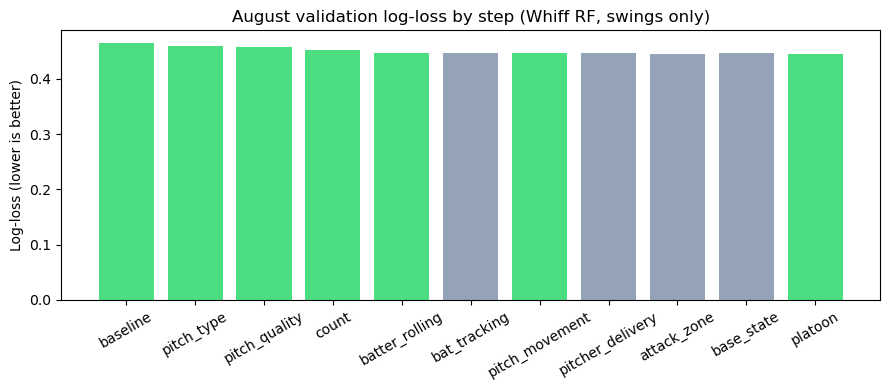

In [4]:
steps_df = pd.DataFrame(report.steps)
colors = ["#4ade80" if kept else "#94a3b8" for kept in steps_df["kept"]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(steps_df["step"], steps_df["val_log_loss"], color=colors)
ax.set_title("August validation log-loss by step (Whiff RF, swings only)")
ax.set_ylabel("Log-loss (lower is better)")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


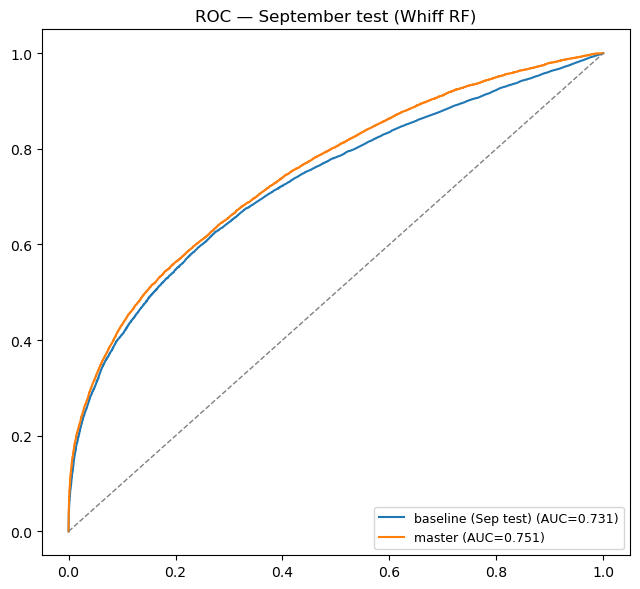

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for result in [baseline_master, master]:
    fpr, tpr = roc_curve_data(result)
    ax.plot(fpr, tpr, label=f"{result.name} (AUC={result.test_roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
ax.set_title("ROC — September test (Whiff RF)")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()


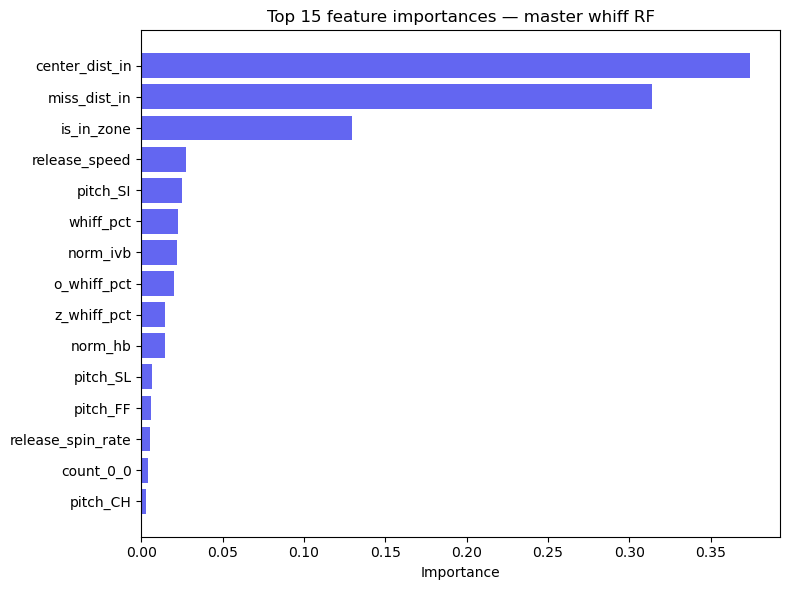

,feature,importance
0,center_dist_in,0.374034
1,miss_dist_in,0.314154
2,is_in_zone,0.129755
3,release_speed,0.027342
4,pitch_SI,0.024762
5,whiff_pct,0.022701
6,norm_ivb,0.021752
7,o_whiff_pct,0.019875
8,z_whiff_pct,0.014486
9,norm_hb,0.014364


In [6]:
top15 = feature_importance_from_model(master.model, SELECTED_FEATURES).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15["feature"][::-1], top15["importance"][::-1], color="#6366f1")
ax.set_title("Top 15 feature importances — master whiff RF")
ax.set_xlabel("Importance")
fig.tight_layout()
plt.show()

display(top15)


## 6. Save production artifact

In [7]:
import joblib

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
ARTIFACT_PATH = MODELS_DIR / "whiff_rf_master.joblib"

artifact = {
    "model": master.model,
    "features": SELECTED_FEATURES,
    "target": TARGET,
    "train_end": str(TRAIN_END.date()),
    "val_end": str(VAL_END.date()),
    "test_log_loss": master.test_log_loss,
    "test_roc_auc": master.test_roc_auc,
    "test_brier": master.test_brier,
}

joblib.dump(artifact, ARTIFACT_PATH)
print(f"Saved master whiff RF -> {ARTIFACT_PATH}")


Saved master whiff RF -> C:\Users\tabshire\Desktop\Portfolio\models\whiff_rf_master.joblib


## 7. Summary

Compare to **`06_modeling_whiff_logr.ipynb`**. Next: **`08` / `09` xwOBAcon**.